In [1]:
import os
import xarray as xr
import numpy as np
import matplotlib
#matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.path as mpath
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cmcrameri import cm as cmc
import cmocean as cmo

## THIS NOTEBOOK NEEDS UPDATING:
now the stats computations are done by a script that places them in a dir named product_stats within every product directory.

SET INPUT OUTPUT FILES AND DIRS FOR PLOTTING

In [2]:
input_dir   = '/home/nicolas/SACO/FRESH-CARE/Data_lstm_reconstruction/arctic_25km/TS_currents_lstm'
input_files = input_dir + '/TS_currents_lstm_*.nc'

output_dir_base = '/home/nicolas/SACO/FRESH-CARE/Data_lstm_reconstruction/arctic_25km/plots'
means_dir_base  = '/home/nicolas/SACO/FRESH-CARE/Data_lstm_reconstruction/arctic_25km/computed_means'

# Subdirs for plots
out_single_date    = os.path.join(output_dir_base, 'single_date')
out_specific_dates = os.path.join(output_dir_base, 'specific_dates_midmonth')
out_seasonal       = os.path.join(output_dir_base, 'seasonal_means')
out_yearly         = os.path.join(output_dir_base, 'yearly_means')
out_grand          = os.path.join(output_dir_base, 'means')

# Parallel computed_means dirs (same structure as plots)
nc_seasonal = os.path.join(means_dir_base, 'seasonal_means')
nc_yearly   = os.path.join(means_dir_base, 'yearly_means')
nc_grand    = os.path.join(means_dir_base, 'means')

for _d in (output_dir_base, out_specific_dates,
           out_seasonal, out_yearly, out_grand,
           means_dir_base, nc_seasonal, nc_yearly, nc_grand):
    os.makedirs(_d, exist_ok=True)


In [3]:
import glob

# Build sorted file list (one file per date, named TS_currents_lstm_YYYYMMDD.nc)
_all_files  = sorted(glob.glob(input_files))
_file_dates = [os.path.basename(f).replace('TS_currents_lstm_', '').replace('.nc', '')
               for f in _all_files]          # e.g. ['20110104', '20110107', ...]
_date_to_file = dict(zip(_file_dates, _all_files))

# Open a single reference file for coordinates, variable attrs and global attrs
_ds_ref = xr.open_dataset(_all_files[0], decode_times=True)

# Build the full time axis from file names (avoids loading all files)
_times_D_all = np.array(
    [np.datetime64(f'{d[:4]}-{d[4:6]}-{d[6:8]}', 'D') for d in _file_dates]
)

print(f'Found {len(_all_files)} files:  {_file_dates[0]}  ..  {_file_dates[-1]}')
print('Reference dataset:')
_ds_ref


Found 1395 files:  20110104  ..  20211228
Reference dataset:


<xarray.Dataset> Size: 836MB
Dimensions:            (time: 1, depth: 102, y_ease: 280, x_ease: 280)
Coordinates:
  * time               (time) datetime64[ns] 8B 2011-01-04T12:00:00
  * depth              (depth) float64 816B 0.0 5.0 10.0 ... 5.4e+03 5.5e+03
  * y_ease             (y_ease) float64 2kB -3.488e+06 -3.462e+06 ... 3.488e+06
  * x_ease             (x_ease) float64 2kB -3.488e+06 -3.462e+06 ... 3.488e+06
Data variables: (12/22)
    T_anom_pred        (time, depth, y_ease, x_ease) float64 64MB ...
    S_anom_pred        (time, depth, y_ease, x_ease) float64 64MB ...
    T_anom_std         (time, depth, y_ease, x_ease) float64 64MB ...
    S_anom_std         (time, depth, y_ease, x_ease) float64 64MB ...
    T_recon            (time, depth, y_ease, x_ease) float64 64MB ...
    S_recon            (time, depth, y_ease, x_ease) float64 64MB ...
    ...                 ...
    DOY                (time) int64 8B ...
    ocean_mask         (y_ease, x_ease) uint8 78kB ...
    elevation          (y_ease, x_ease) float64 627kB ...
    latitude           (y_ease, x_ease) float64 627kB ...
    longitude          (y_ease, x_ease) float64 627kB ...
    ease_grid_mapping  int64 8B ...
Attributes: (12/25)
    title:                       Arctic 4-D ocean reconstruction (ease_25km, ...
    summary:                     Arctic 4-D ocean reconstruction (ease_25km, ...
    Conventions:                 CF-1.8, ACDD-1.3
    source:                      LSTM with Monte-Carlo Dropout, trained on Ar...
    history:                     2026-05-12T13:45:37Z: file created
    creation_date:               2026-05-12T13:45:37Z
    ...                          ...
    model_path:                  /home/nicolas/SACO/FRESH-CARE/Codes/WP2/buon...
    glorys_mode:                 daily
    n_mc_samples:                500
    satellite_time_window_days:  16
    reconstruction_date:         2011-01-04
    geospatial_lat_min:          60.0

In [4]:
# Variable plotting configuration
plot_config = {
    'T_recon': {
        'colormap': 'cmo.thermal',
        'vmin': -2,
        'vmax': 11,
        'units': '°C',
    },
    'S_recon': {
        'colormap': 'cmo.haline',
        'vmin': 26,
        'vmax': 36,
        'units': '',
    },
    'T_anom_pred': {
        'colormap': 'cmc.vik',
        'vmin': -1,
        'vmax': 1,
        'units': '°C',
    },
    'S_anom_pred': {
        'colormap': 'cmc.vik',
        'vmin': -1.1,
        'vmax': 1.1,
        'units': '',
    },
}

# Depths used in every 4-panel composite (meters)
plotting_depths = [0, 30, 100, 800]

# Variable used by the single-date preview cell below
desired_variable = 'S_anom_pred'  # Change to 'T_recon', 'S_recon', 'T_anom_pred', or 'S_anom_pred' as needed
cfg = plot_config[desired_variable]

# Single date to preview (YYYY-MM-DD). Used only by the single-date cell.
# Set to None to fall back to the first time step of the dataset.
single_date = '2015-08-16'


PLOT JUST ONE DATE FOR A START

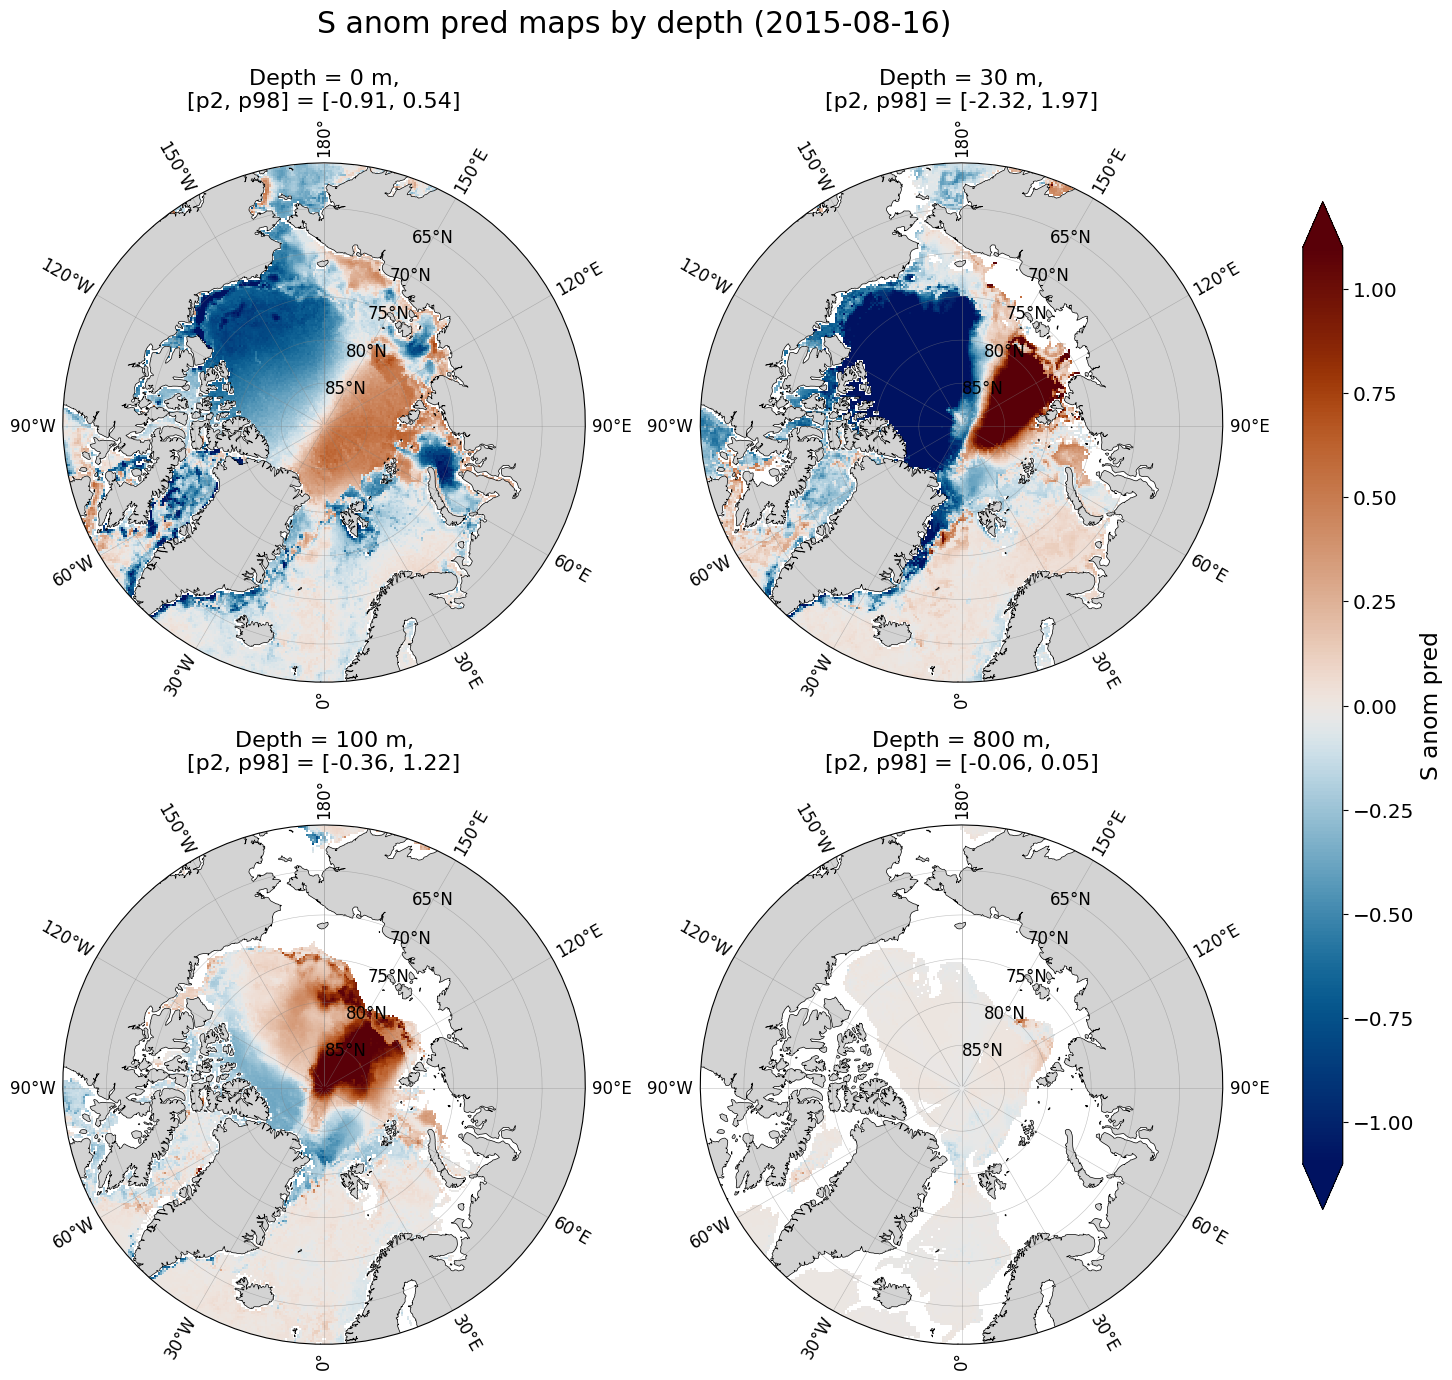

9

In [5]:

import gc
import matplotlib.cm as _cm
import matplotlib.colors as _mcolors

# Define EASE projection (Lambert Azimuthal Equal-Area, North Pole)
ease_crs = ccrs.LambertAzimuthalEqualArea(central_latitude=90, central_longitude=0)

# Extract EASE coordinates from reference file (1-D → 2-D meshgrid)
x_ease = _ds_ref['x_ease'].values
y_ease = _ds_ref['y_ease'].values
if x_ease.ndim == 1 and y_ease.ndim == 1:
    x_ease, y_ease = np.meshgrid(x_ease, y_ease)

# --- pick the requested date and verify it is in the file list ---
if single_date is None:
    sel_date_str = _file_dates[0]
else:
    sel_date_str = single_date.replace('-', '')
    if sel_date_str not in _date_to_file:
        raise ValueError(
            f"single_date={single_date!r} is not present in the file list "
            f"(range: {_file_dates[0]} .. {_file_dates[-1]})"
        )
time0_compact = sel_date_str
time0_str = f'{sel_date_str[:4]}-{sel_date_str[4:6]}-{sel_date_str[6:]}'

vmin = cfg['vmin']
vmax = cfg['vmax']
cmap_name = cfg['colormap']
units = cfg['units']

# Open only the single file for this date
with xr.open_dataset(_date_to_file[sel_date_str], decode_times=True) as _ds_day:
    depth_values = _ds_day['depth'].values

    # Draw all 4 panels directly into a single 2×2 figure — no PNG round-trip.
    fig, axes = plt.subplots(2, 2, figsize=(16, 16),
                             subplot_kw={'projection': ccrs.NorthPolarStereo()})

    for ax, depth_target in zip(axes.flatten(), plotting_depths):
        depth_idx = int(np.abs(depth_values - depth_target).argmin())
        depth_used = float(depth_values[depth_idx])
        data = _ds_day[desired_variable].isel(depth=depth_idx, time=0).values

        ax.set_extent([-180, 180, 60, 90], crs=ccrs.PlateCarree())
        ax.add_feature(cfeature.LAND, facecolor='lightgray')
        ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
        gl = ax.gridlines(draw_labels=True, linewidth=0.4, color='gray', alpha=0.5)
        gl.xlocator = plt.MultipleLocator(30)
        gl.ylocator = plt.MultipleLocator(5)
        gl.xlabel_style = {'size': 12}
        gl.ylabel_style = {'size': 12}

        _theta = np.linspace(0, 2 * np.pi, 100)
        _verts = np.vstack([np.sin(_theta), np.cos(_theta)]).T
        ax.set_boundary(mpath.Path(_verts * 0.5 + [0.5, 0.5]), transform=ax.transAxes)

        ax.pcolormesh(x_ease, y_ease, data, cmap=cmap_name, transform=ease_crs,
                      vmin=vmin, vmax=vmax, shading='auto')

        p02 = np.nanpercentile(data, 2)
        p98 = np.nanpercentile(data, 98)
        u = f' {units}' if units else ''
        title = (f'Depth = {depth_used:.0f} m,\n'
                 f'[p2, p98] = [{p02:.2f}, {p98:.2f}]{u}')
        ax.set_title(title, fontsize=16)

display_name = desired_variable.replace('_', ' ')
cbar_label = f'{display_name} [{units}]' if units else display_name
fig.suptitle(f'{display_name} maps by depth ({time0_str})      ',
             fontsize=21.6, y=0.97)
fig.subplots_adjust(top=0.90, right=0.85, hspace=0.10, wspace=0.22)

_sm = _cm.ScalarMappable(cmap=cmap_name, norm=_mcolors.Normalize(vmin=vmin, vmax=vmax))
_sm.set_array([])
cbar_ax = fig.add_axes([0.90, 0.22, 0.025, 0.63])
cbar = fig.colorbar(_sm, cax=cbar_ax, extend='both')
cbar.set_label(cbar_label, fontsize=16.8)
cbar.ax.tick_params(labelsize=14.4)

path = os.path.join(out_single_date,
                    f'{time0_compact}_{desired_variable}_maps_4depths.png')
# os.makedirs(os.path.dirname(path), exist_ok=True)
# plt.savefig(path, dpi=350, bbox_inches='tight')
plt.show()
plt.close(fig)
gc.collect()


SHARED CONFIG + HELPERS FOR BATCH PLOTS (specific dates, seasonal, yearly, grand mean)

In [6]:

# Shared config & helpers for every batch-plotting cell below.
import datetime, gc
import matplotlib.cm as _cm
import matplotlib.colors as _mcolors

# --- year range (inclusive) used by every batch cell ---
batch_year_start = 2011
batch_year_end   = 2021

# Validate variables in plot_config are actually present in the reference file.
for _v in plot_config:
    if _v not in _ds_ref.data_vars:
        raise KeyError(
            f"Variable {_v!r} from plot_config is missing in the dataset. "
            f"Available: {list(_ds_ref.data_vars)}"
        )

# EASE coords (2D meshgrid), reused by every plot
_x_e = _ds_ref['x_ease'].values
_y_e = _ds_ref['y_ease'].values
if _x_e.ndim == 1 and _y_e.ndim == 1:
    _x_e, _y_e = np.meshgrid(_x_e, _y_e)

ease_crs = ccrs.LambertAzimuthalEqualArea(central_latitude=90, central_longitude=0)

# Time axis derived from file names (no full mfdataset needed)
_years_all  = np.array([int(d[:4]) for d in _file_dates])
_months_all = np.array([int(d[4:6]) for d in _file_dates])

# Restrict to requested year range once
_in_range = (_years_all >= batch_year_start) & (_years_all <= batch_year_end)
print(f'Times in [{batch_year_start},{batch_year_end}]: '
      f'{int(_in_range.sum())} / {len(_file_dates)}')

_depth_values = _ds_ref['depth'].values

# Pre-compute depth indices for the plotting depths (shared by all batch cells)
_depth_idx_sel = sorted({int(np.abs(_depth_values - d).argmin())
                         for d in plotting_depths})
_depth_vals_sel = _depth_values[_depth_idx_sel]
print(f'Reading only depth indices {_depth_idx_sel} '
      f'(depths {_depth_vals_sel.tolist()} m)')


# ── per-variable computed_means subdirs (one per var, matching plot subdirs) ──

def _nc_var_dir(nc_base, var):
    """Return (and create) the per-variable subdir under a computed_means base."""
    d = os.path.join(nc_base, var)
    os.makedirs(d, exist_ok=True)
    return d


# ── helpers: save / load a mean NC file ──────────────────────────────────────

def _save_mean_nc(mean_arr, var, depth_indices, out_path, mean_label):
    """Save a computed mean array as a CF-compliant NetCDF file."""
    depth_vals = _depth_values[depth_indices]
    now_str = datetime.datetime.now(datetime.UTC).strftime('%Y-%m-%dT%H:%M:%SZ')

    ds_out = xr.Dataset(
        {
            var: xr.DataArray(
                mean_arr,
                dims=['depth', 'y_ease', 'x_ease'],
                attrs={**dict(_ds_ref[var].attrs), 'cell_methods': 'time: mean'},
            )
        },
        coords={
            'depth':  ('depth',  depth_vals,            dict(_ds_ref['depth'].attrs)),
            'y_ease': ('y_ease', _ds_ref['y_ease'].values, dict(_ds_ref['y_ease'].attrs)),
            'x_ease': ('x_ease', _ds_ref['x_ease'].values, dict(_ds_ref['x_ease'].attrs)),
        },
        attrs={
            **{k: v for k, v in _ds_ref.attrs.items()
               if k not in ('history', 'creation_date', 'reconstruction_date')},
            'mean_type':    mean_label,
            'history':      f'{now_str}: mean computed from daily reconstruction files',
            'creation_date': now_str,
        }
    )
    ds_out.to_netcdf(out_path)
    ds_out.close()
    print(f'    Saved NC: {os.path.basename(out_path)}')


def _load_mean_nc(nc_path, var):
    """Load a mean array from a saved NC file.  Returns ndarray (depth, y, x)."""
    with xr.open_dataset(nc_path) as f:
        arr = f[var].values.copy()
    return arr


# ── plotting helper ───────────────────────────────────────────────────────────

def _plot_4panel(data_dyx, depth_values, var, depths_m, out_path, title_extra=''):
    """Plot 4-depth composite for one variable and save to PNG."""
    cfg_v = plot_config[var]
    vmin, vmax, cmap_name = cfg_v['vmin'], cfg_v['vmax'], cfg_v['colormap']
    units = cfg_v['units']

    fig, axes = plt.subplots(2, 2, figsize=(16, 16),
                             subplot_kw={'projection': ccrs.NorthPolarStereo()})

    for ax, depth_target in zip(axes.flatten(), depths_m):
        depth_idx = int(np.abs(depth_values - depth_target).argmin())
        depth_used = float(depth_values[depth_idx])
        data = data_dyx[depth_idx]

        ax.set_extent([-180, 180, 60, 90], crs=ccrs.PlateCarree())
        ax.add_feature(cfeature.LAND, facecolor='lightgray')
        ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
        gl = ax.gridlines(draw_labels=True, linewidth=0.4, color='gray', alpha=0.5)
        gl.xlocator = plt.MultipleLocator(30)
        gl.ylocator = plt.MultipleLocator(5)
        gl.xlabel_style = {'size': 12}
        gl.ylabel_style = {'size': 12}

        _theta = np.linspace(0, 2 * np.pi, 100)
        _verts = np.vstack([np.sin(_theta), np.cos(_theta)]).T
        ax.set_boundary(mpath.Path(_verts * 0.5 + [0.5, 0.5]),
                        transform=ax.transAxes)

        ax.pcolormesh(_x_e, _y_e, data, cmap=cmap_name, transform=ease_crs,
                      vmin=vmin, vmax=vmax, shading='auto')

        p02 = np.nanpercentile(data, 2)
        p98 = np.nanpercentile(data, 98)
        u = f' {units}' if units else ''
        title = (f'Depth = {depth_used:.0f} m,\n'
                 f'[p2, p98] = [{p02:.2f}, {p98:.2f}]{u}')
        ax.set_title(title, fontsize=16)

    display_name = var.replace('_', ' ')
    cbar_label = f'{display_name} [{units}]' if units else display_name
    fig.suptitle(f'{display_name} maps by depth ({title_extra})      ',
                 fontsize=21.6, y=0.97)
    fig.subplots_adjust(top=0.90, right=0.85, hspace=0.10, wspace=0.22)

    _sm = _cm.ScalarMappable(cmap=cmap_name,
                             norm=_mcolors.Normalize(vmin=vmin, vmax=vmax))
    _sm.set_array([])
    cbar_ax = fig.add_axes([0.90, 0.22, 0.025, 0.63])
    cbar = fig.colorbar(_sm, cax=cbar_ax, extend='both')
    cbar.set_label(cbar_label, fontsize=16.8)
    cbar.ax.tick_params(labelsize=14.4)

    fig.savefig(out_path, dpi=350, bbox_inches='tight')
    plt.close(fig)
    gc.collect()


# ── RAM-safe incremental mean (opens one file at a time) ─────────────────────

def incremental_mean(date_strings, vars_list, label='', depth_indices=None):
    """NaN-aware mean over a list of daily file dates."""
    n = len(date_strings)
    if n == 0:
        raise ValueError(f'No dates provided for label {label!r}')

    sums   = {v: None for v in vars_list}
    counts = {v: None for v in vars_list}

    for k, date_str in enumerate(date_strings):
        fpath = _date_to_file[date_str]
        with xr.open_dataset(fpath, decode_times=True) as f:
            for v in vars_list:
                if depth_indices is not None:
                    arr = f[v].isel(time=0, depth=depth_indices).values.astype(np.float64)
                else:
                    arr = f[v].isel(time=0).values.astype(np.float64)
                mask = np.isfinite(arr)
                if sums[v] is None:
                    sums[v]   = np.where(mask, arr, 0.0)
                    counts[v] = mask.astype(np.int64)
                else:
                    sums[v]   += np.where(mask, arr, 0.0)
                    counts[v] += mask
                del arr, mask
        if (k + 1) % 50 == 0 or (k + 1) == n:
            print(f'  [{label}] {k + 1}/{n}')

    means = {}
    for v in vars_list:
        with np.errstate(invalid='ignore', divide='ignore'):
            m = sums[v] / counts[v]
        m[counts[v] == 0] = np.nan
        means[v] = m
    del sums, counts
    gc.collect()
    return means


Times in [2011,2021]: 1395 / 1395
Reading only depth indices [0, 6, 20, 42] (depths [0.0, 30.0, 100.0, 800.0] m)


PLOT ALL VARIABLES ON SPECIFIC MID-MONTH DATES (Feb 16, May 16, Aug 16, Nov 16) ACROSS YEARS

In [22]:

# Specific mid-month dates: Feb 16, May 16, Aug 16, Nov 16 for each year
# in [batch_year_start, batch_year_end]. One PNG per (variable, date).
# (Dataset has 3-day resolution, so day 15 is not present; using day 16.)

SKIP_EXISTING = True  # Set to False to overwrite existing files.

target_months_days = [(2, 16), (5, 16), (8, 16), (11, 16)]

# Per-variable subdir under out_specific_dates
var_out = {}
for v in plot_config:
    sub = os.path.join(out_specific_dates, v)
    os.makedirs(sub, exist_ok=True)
    var_out[v] = sub

# Build the list of compact date strings that exist in the file list
selected = []
missing  = []
for yr in range(batch_year_start, batch_year_end + 1):
    for mo, dy in target_months_days:
        compact = f'{yr:04d}{mo:02d}{dy:02d}'
        if compact in _date_to_file:
            selected.append(compact)
        else:
            missing.append(f'{yr:04d}-{mo:02d}-{dy:02d}')

print(f'Selected {len(selected)} dates; missing {len(missing)}')
if missing:
    print('  missing:', missing)

# _depth_idx_sel and _depth_vals_sel are pre-computed in the shared config cell.
print(f'Reading only depth indices {_depth_idx_sel} '
      f'(depths {_depth_vals_sel.tolist()} m)')

for compact in selected:
    date_iso = f'{compact[:4]}-{compact[4:6]}-{compact[6:]}'
    for var in plot_config:
        out_png = os.path.join(var_out[var],
                               f'{compact}_{var}_maps_4depths.png')
        if SKIP_EXISTING and os.path.exists(out_png):
            continue
        # Load only the selected depth slices from this date's file.
        with xr.open_dataset(_date_to_file[compact], decode_times=True) as _ds_day:
            data_dyx = _ds_day[var].isel(time=0, depth=_depth_idx_sel).values
        _plot_4panel(data_dyx, _depth_vals_sel, var,
                     plotting_depths, out_png, title_extra=date_iso)
        del data_dyx
        gc.collect()
    print(f'  done {date_iso}')

print('Specific-date plotting finished.')


Selected 44 dates; missing 0
Reading only depth indices [0, 6, 20, 42] (depths [0.0, 30.0, 100.0, 800.0] m)
  done 2011-02-16
  done 2011-05-16
  done 2011-08-16
  done 2011-11-16
  done 2012-02-16
  done 2012-05-16
  done 2012-08-16
  done 2012-11-16
  done 2013-02-16
  done 2013-05-16
  done 2013-08-16
  done 2013-11-16
  done 2014-02-16
  done 2014-05-16
  done 2014-08-16
  done 2014-11-16
  done 2015-02-16
  done 2015-05-16
  done 2015-08-16
  done 2015-11-16
  done 2016-02-16
  done 2016-05-16
  done 2016-08-16
  done 2016-11-16
  done 2017-02-16
  done 2017-05-16
  done 2017-08-16
  done 2017-11-16
  done 2018-02-16
  done 2018-05-16
  done 2018-08-16
  done 2018-11-16
  done 2019-02-16
  done 2019-05-16
  done 2019-08-16
  done 2019-11-16
  done 2020-02-16
  done 2020-05-16
  done 2020-08-16
  done 2020-11-16
  done 2021-02-16
  done 2021-05-16
  done 2021-08-16
  done 2021-11-16
Specific-date plotting finished.


PLOT SEASONAL AVERAGES OVER A TIME RANGE

In [7]:

# Seasonal means per year (DJF, MAM, JJA, SON).
# DJF year convention: Dec(Y-1) + Jan(Y) + Feb(Y)  →  labelled {Y}_DJF.
# Means are saved as NC files and re-used on subsequent runs.

USE_EXISTING_COMPUTATION = True  # Load pre-computed mean NC if it exists; False to recompute+overwrite.
SKIP_EXISTING            = True  # Skip PNG generation if the file already exists.

_MONTH_TO_SEASON = {
    12: 'DJF', 1: 'DJF', 2: 'DJF',
    3:  'MAM', 4: 'MAM', 5: 'MAM',
    6:  'JJA', 7: 'JJA', 8: 'JJA',
    9:  'SON', 10: 'SON', 11: 'SON',
}

# Per-variable plot subdirs
for v in plot_config:
    os.makedirs(os.path.join(out_seasonal, v), exist_ok=True)

# Group file dates by (label_year, season).
# DJF: December of year Y contributes to label_year = Y+1.
# All other seasons: label_year = year of the file.
from collections import defaultdict
season_year_dates = defaultdict(list)  # key: (label_year, season)

for i, d in enumerate(_file_dates):
    if not _in_range[i]:
        continue
    yr  = _years_all[i]
    mo  = _months_all[i]
    sea = _MONTH_TO_SEASON[mo]
    label_year = yr + 1 if mo == 12 else yr
    # Exclude DJF labels that fall outside the requested year range
    if batch_year_start <= label_year <= batch_year_end:
        season_year_dates[(label_year, sea)].append(d)

for (yr, sea), dates in sorted(season_year_dates.items()):
    print(f'{yr}_{sea}: {len(dates)} time steps')

for (label_year, season), dates in sorted(season_year_dates.items()):
    if not dates:
        continue

    pfx         = f'{label_year}_{season}'
    title_extra = f'{season} {label_year}'

    # ── Step 1: compute & save missing NC means (one pass over files) ──────
    vars_to_compute = []
    for var in plot_config:
        nc_path = os.path.join(_nc_var_dir(nc_seasonal, var), f'{pfx}_{var}_mean.nc')
        if USE_EXISTING_COMPUTATION and os.path.exists(nc_path):
            print(f'  NC exists, skipping computation: {pfx} {var}')
        else:
            vars_to_compute.append(var)

    if vars_to_compute:
        print(f'Computing {pfx} mean ({len(dates)} steps, vars: {vars_to_compute})...')
        new_means = incremental_mean(dates, vars_to_compute, label=pfx,
                                     depth_indices=_depth_idx_sel)
        for var in vars_to_compute:
            nc_path = os.path.join(_nc_var_dir(nc_seasonal, var), f'{pfx}_{var}_mean.nc')
            _save_mean_nc(new_means[var], var, _depth_idx_sel, nc_path,
                          f'{season} mean {label_year}')
        del new_means; gc.collect()

    # ── Step 2: plot (always loading from NC) ──────────────────────────────
    for var in plot_config:
        out_png = os.path.join(out_seasonal, var, f'{pfx}_{var}_maps_4depths.png')
        if SKIP_EXISTING and os.path.exists(out_png):
            print(f'  PNG exists, skipping plot: {pfx} {var}')
            continue
        nc_path = os.path.join(_nc_var_dir(nc_seasonal, var), f'{pfx}_{var}_mean.nc')
        mean_arr = _load_mean_nc(nc_path, var)
        _plot_4panel(mean_arr, _depth_vals_sel, var, plotting_depths, out_png,
                     title_extra=title_extra)
        del mean_arr; gc.collect()

    print(f'  {pfx} done.')

print('Seasonal batch plotting finished.')


2011_DJF: 20 time steps
2011_JJA: 32 time steps
2011_MAM: 32 time steps
2011_SON: 31 time steps
2012_DJF: 32 time steps
2012_JJA: 32 time steps
2012_MAM: 32 time steps
2012_SON: 31 time steps
2013_DJF: 32 time steps
2013_JJA: 32 time steps
2013_MAM: 32 time steps
2013_SON: 31 time steps
2014_DJF: 32 time steps
2014_JJA: 32 time steps
2014_MAM: 32 time steps
2014_SON: 31 time steps
2015_DJF: 32 time steps
2015_JJA: 32 time steps
2015_MAM: 32 time steps
2015_SON: 31 time steps
2016_DJF: 32 time steps
2016_JJA: 32 time steps
2016_MAM: 32 time steps
2016_SON: 31 time steps
2017_DJF: 32 time steps
2017_JJA: 32 time steps
2017_MAM: 32 time steps
2017_SON: 31 time steps
2018_DJF: 32 time steps
2018_JJA: 32 time steps
2018_MAM: 32 time steps
2018_SON: 31 time steps
2019_DJF: 32 time steps
2019_JJA: 32 time steps
2019_MAM: 32 time steps
2019_SON: 31 time steps
2020_DJF: 32 time steps
2020_JJA: 32 time steps
2020_MAM: 32 time steps
2020_SON: 31 time steps
2021_DJF: 32 time steps
2021_JJA: 32 tim

PLOT YEARLY AVERAGES

In [8]:

# Yearly means across [batch_year_start, batch_year_end].
# Means are saved as NC files and re-used on subsequent runs.

USE_EXISTING_COMPUTATION = True  # Load pre-computed mean NC if it exists; False to recompute+overwrite.
SKIP_EXISTING            = False  # Skip PNG generation if the file already exists.

# Per-variable plot subdirs
for v in plot_config:
    os.makedirs(os.path.join(out_yearly, v), exist_ok=True)

for yr in range(batch_year_start, batch_year_end + 1):
    yr_dates = [d for d, y in zip(_file_dates, _years_all) if y == yr]
    if not yr_dates:
        print(f'Skipping {yr} (no data).')
        continue

    # ── Step 1: compute & save missing NC means (one pass over files) ──────
    vars_to_compute = []
    for var in plot_config:
        nc_path = os.path.join(_nc_var_dir(nc_yearly, var), f'{yr}_{var}_mean.nc')
        if USE_EXISTING_COMPUTATION and os.path.exists(nc_path):
            print(f'  NC exists, skipping computation: {yr} {var}')
        else:
            vars_to_compute.append(var)

    if vars_to_compute:
        print(f'Computing {yr} mean ({len(yr_dates)} steps, vars: {vars_to_compute})...')
        new_means = incremental_mean(yr_dates, vars_to_compute, label=str(yr),
                                     depth_indices=_depth_idx_sel)
        for var in vars_to_compute:
            nc_path = os.path.join(_nc_var_dir(nc_yearly, var), f'{yr}_{var}_mean.nc')
            _save_mean_nc(new_means[var], var, _depth_idx_sel, nc_path,
                          f'{yr} annual mean')
        del new_means; gc.collect()

    # ── Step 2: plot (always loading from NC) ──────────────────────────────
    for var in plot_config:
        out_png = os.path.join(out_yearly, var, f'{yr}_{var}_maps_4depths.png')
        if SKIP_EXISTING and os.path.exists(out_png):
            print(f'  PNG exists, skipping plot: {yr} {var}')
            continue
        nc_path = os.path.join(_nc_var_dir(nc_yearly, var), f'{yr}_{var}_mean.nc')
        mean_arr = _load_mean_nc(nc_path, var)
        _plot_4panel(mean_arr, _depth_vals_sel, var, plotting_depths, out_png,
                     title_extra=f'{yr} mean')
        del mean_arr; gc.collect()

    print(f'  {yr} done.')

print('Yearly batch plotting finished.')


  NC exists, skipping computation: 2011 T_recon
  NC exists, skipping computation: 2011 S_recon
  NC exists, skipping computation: 2011 T_anom_pred
  NC exists, skipping computation: 2011 S_anom_pred
  2011 done.
  NC exists, skipping computation: 2012 T_recon
  NC exists, skipping computation: 2012 S_recon
  NC exists, skipping computation: 2012 T_anom_pred
  NC exists, skipping computation: 2012 S_anom_pred
  2012 done.
  NC exists, skipping computation: 2013 T_recon
  NC exists, skipping computation: 2013 S_recon
  NC exists, skipping computation: 2013 T_anom_pred
  NC exists, skipping computation: 2013 S_anom_pred
  2013 done.
  NC exists, skipping computation: 2014 T_recon
  NC exists, skipping computation: 2014 S_recon
  NC exists, skipping computation: 2014 T_anom_pred
  NC exists, skipping computation: 2014 S_anom_pred
  2014 done.
  NC exists, skipping computation: 2015 T_recon
  NC exists, skipping computation: 2015 S_recon
  NC exists, skipping computation: 2015 T_anom_pred


PLOT GRAND MEAN OVER THE FULL DATE RANGE

In [ ]:

# Grand mean over all time steps in [batch_year_start, batch_year_end].
# Means are saved as NC files and re-used on subsequent runs.

USE_EXISTING_COMPUTATION = True  # Load pre-computed mean NC if it exists; False to recompute+overwrite.
SKIP_EXISTING            = False  # Skip PNG generation if the file already exists.

os.makedirs(nc_grand, exist_ok=True)
pfx = f'{batch_year_start}_{batch_year_end}'
title_extra = f'grand mean {batch_year_start}-{batch_year_end}'

# ── Step 1: compute & save missing NC means (one pass over files) ──────────
all_dates = [d for d, r in zip(_file_dates, _in_range) if r]
vars_to_compute = []
for var in plot_config:
    nc_path = os.path.join(nc_grand, f'{pfx}_grandmean_{var}_mean.nc')
    if USE_EXISTING_COMPUTATION and os.path.exists(nc_path):
        print(f'  NC exists, skipping computation: grand mean {var}')
    else:
        vars_to_compute.append(var)

if vars_to_compute:
    print(f'Computing grand mean ({len(all_dates)} steps, vars: {vars_to_compute})...')
    new_means = incremental_mean(all_dates, vars_to_compute, label='grand',
                                 depth_indices=_depth_idx_sel)
    for var in vars_to_compute:
        nc_path = os.path.join(nc_grand, f'{pfx}_grandmean_{var}_mean.nc')
        _save_mean_nc(new_means[var], var, _depth_idx_sel, nc_path,
                      f'grand mean {batch_year_start}-{batch_year_end}')
    del new_means; gc.collect()

# ── Step 2: plot (always loading from NC) ──────────────────────────────────
for var in plot_config:
    out_png = os.path.join(out_grand, f'{pfx}_grandmean_{var}_maps_4depths.png')
    if SKIP_EXISTING and os.path.exists(out_png):
        print(f'  PNG exists, skipping plot: grand mean {var}')
        continue
    nc_path = os.path.join(nc_grand, f'{pfx}_grandmean_{var}_mean.nc')
    mean_arr = _load_mean_nc(nc_path, var)
    _plot_4panel(mean_arr, _depth_vals_sel, var, plotting_depths, out_png,
                 title_extra=title_extra)
    del mean_arr; gc.collect()

print('Grand-mean plotting finished.')


  NC exists, skipping computation: grand mean T_recon
  NC exists, skipping computation: grand mean S_recon
  NC exists, skipping computation: grand mean T_anom_pred
  NC exists, skipping computation: grand mean S_anom_pred
Grand-mean plotting finished.
